In [3]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv('/content/hotel_bookings.csv')

# **Exploratory Data Analysis** *(EDA)*

In [6]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [7]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [8]:
print(df.shape)

(119390, 32)


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [10]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [11]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [12]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

# *Data Cleaning*

In [13]:
df = df[~(
    (df["adults"] == 0) &
    (df["children"] == 0) &
    (df["babies"] == 0)
)]

In [14]:
df["adults"].value_counts().sort_index()

,count
adults,
0,223
1,23027
2,89680
3,6202
4,62
5,2
6,1
10,1
20,2


In [16]:
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

In [17]:
df[(df[numeric_columns] < 0).any(axis=1)]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
14969,Resort Hotel,0,195,2017,March,10,5,4,6,2,...,No Deposit,273.0,NaN,0,Transient-Party,-6.38,0,0,Check-Out,2017-03-15


In [18]:
df = df[df['adr'] >= 0]


In [19]:
(df[numeric_columns] < 0).sum()

,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0
children,0
babies,0


In [20]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [22]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 31980


#*Data Visualization*

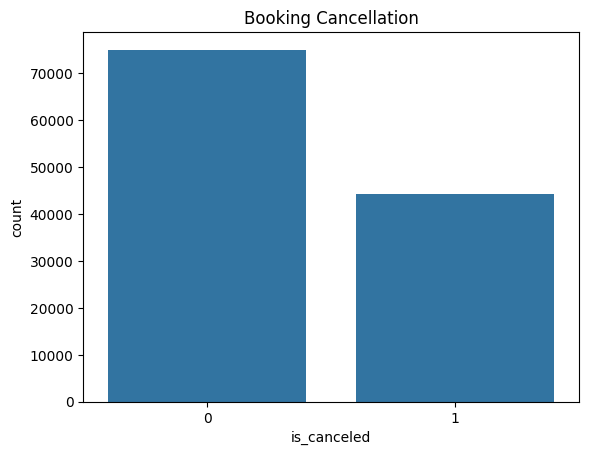

In [21]:
sns.countplot(x='is_canceled', data=df)
plt.title("Booking Cancellation")
plt.show()

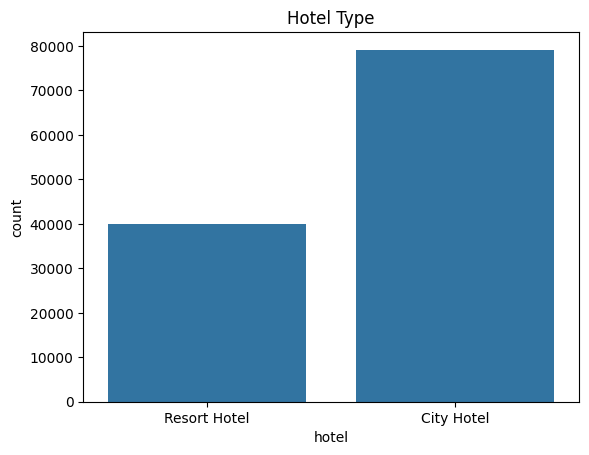

In [23]:
sns.countplot(x='hotel', data=df)
plt.title("Hotel Type")
plt.show()

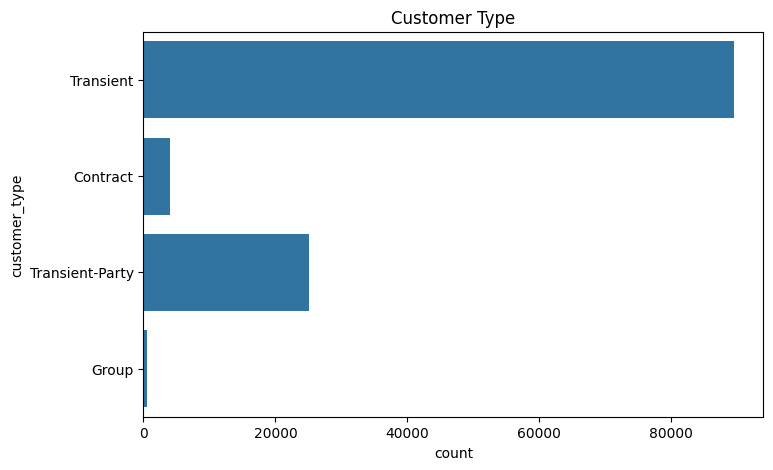

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(y='customer_type', data=df)
plt.title("Customer Type")
plt.show()

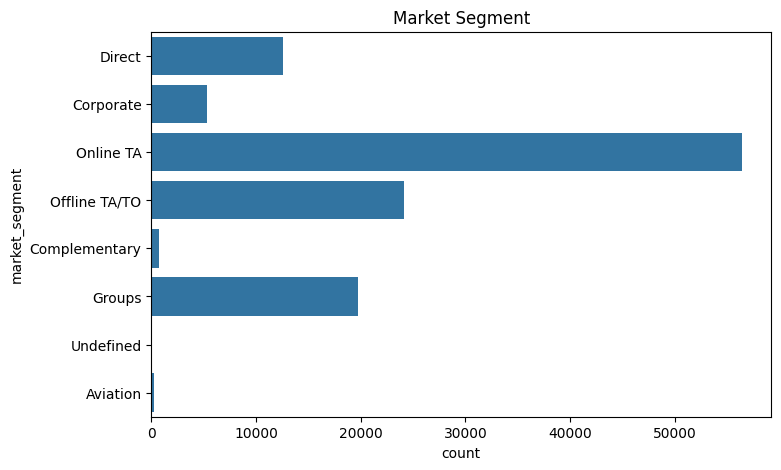

In [25]:
plt.figure(figsize=(8,5))
sns.countplot(y='market_segment', data=df)
plt.title("Market Segment")
plt.show()

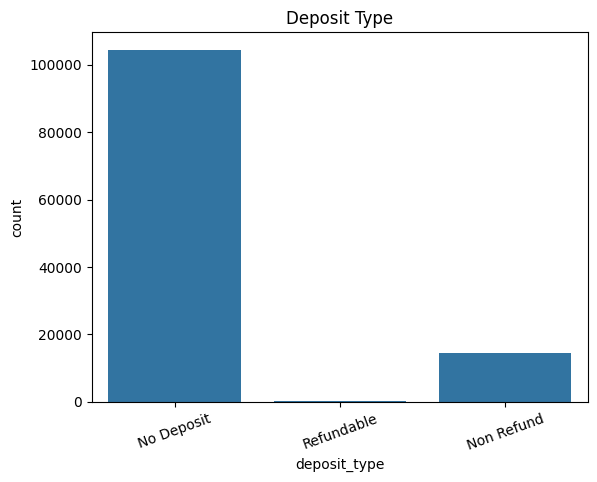

In [26]:
sns.countplot(x='deposit_type', data=df)
plt.title("Deposit Type")
plt.xticks(rotation=20)
plt.show()

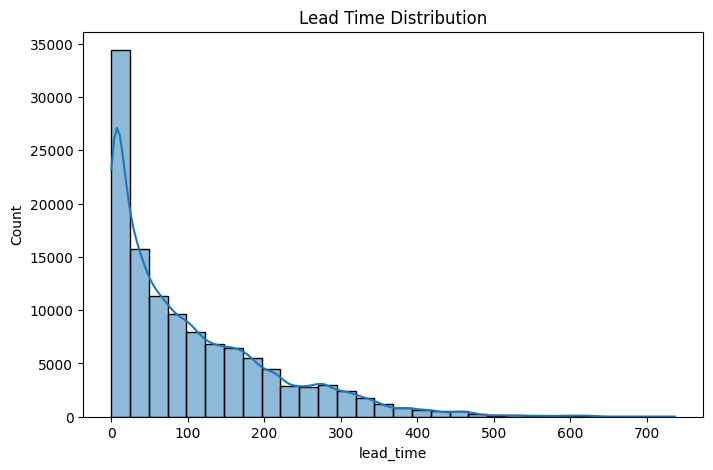

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df['lead_time'], bins=30, kde=True)
plt.title("Lead Time Distribution")
plt.show()

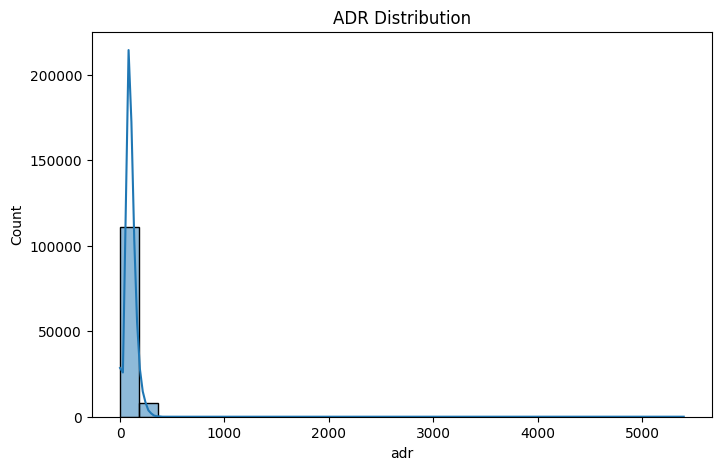

In [28]:
plt.figure(figsize=(8,5))
sns.histplot(df['adr'], bins=30, kde=True)
plt.title("ADR Distribution")
plt.show()

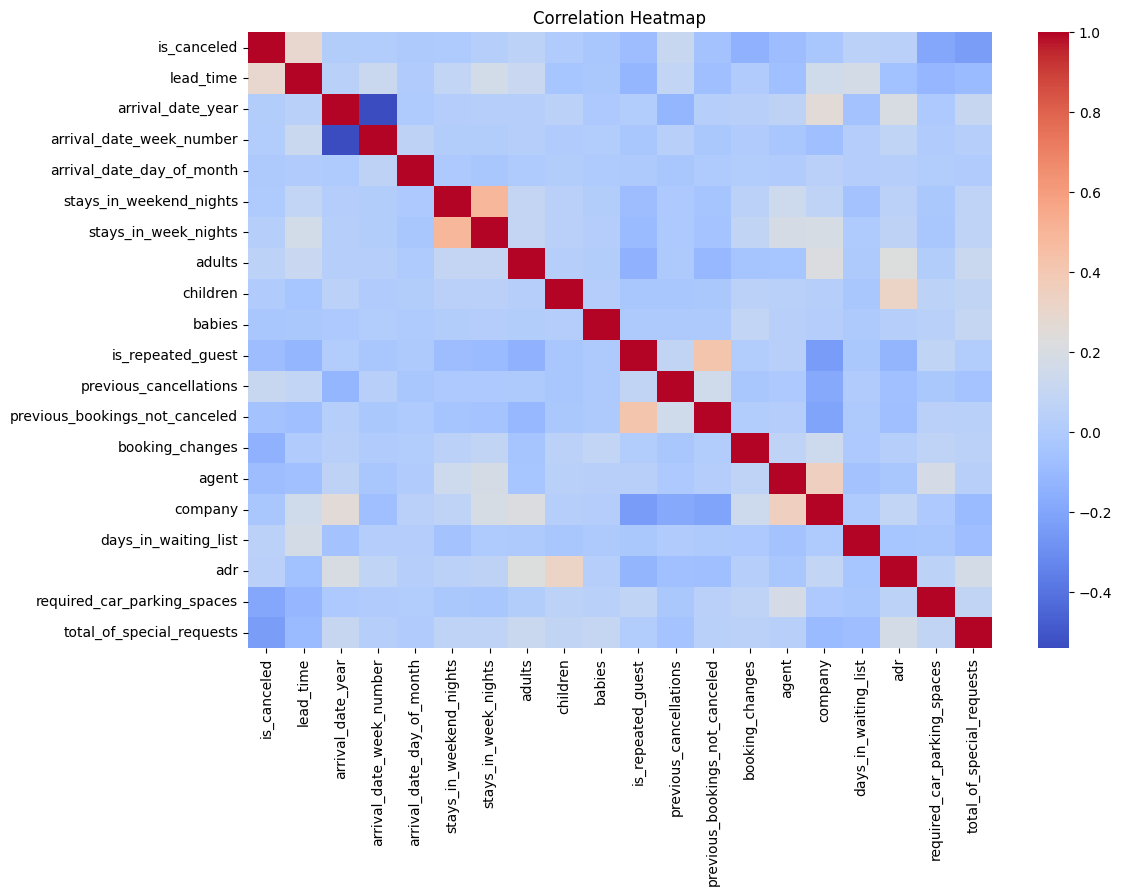

In [29]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

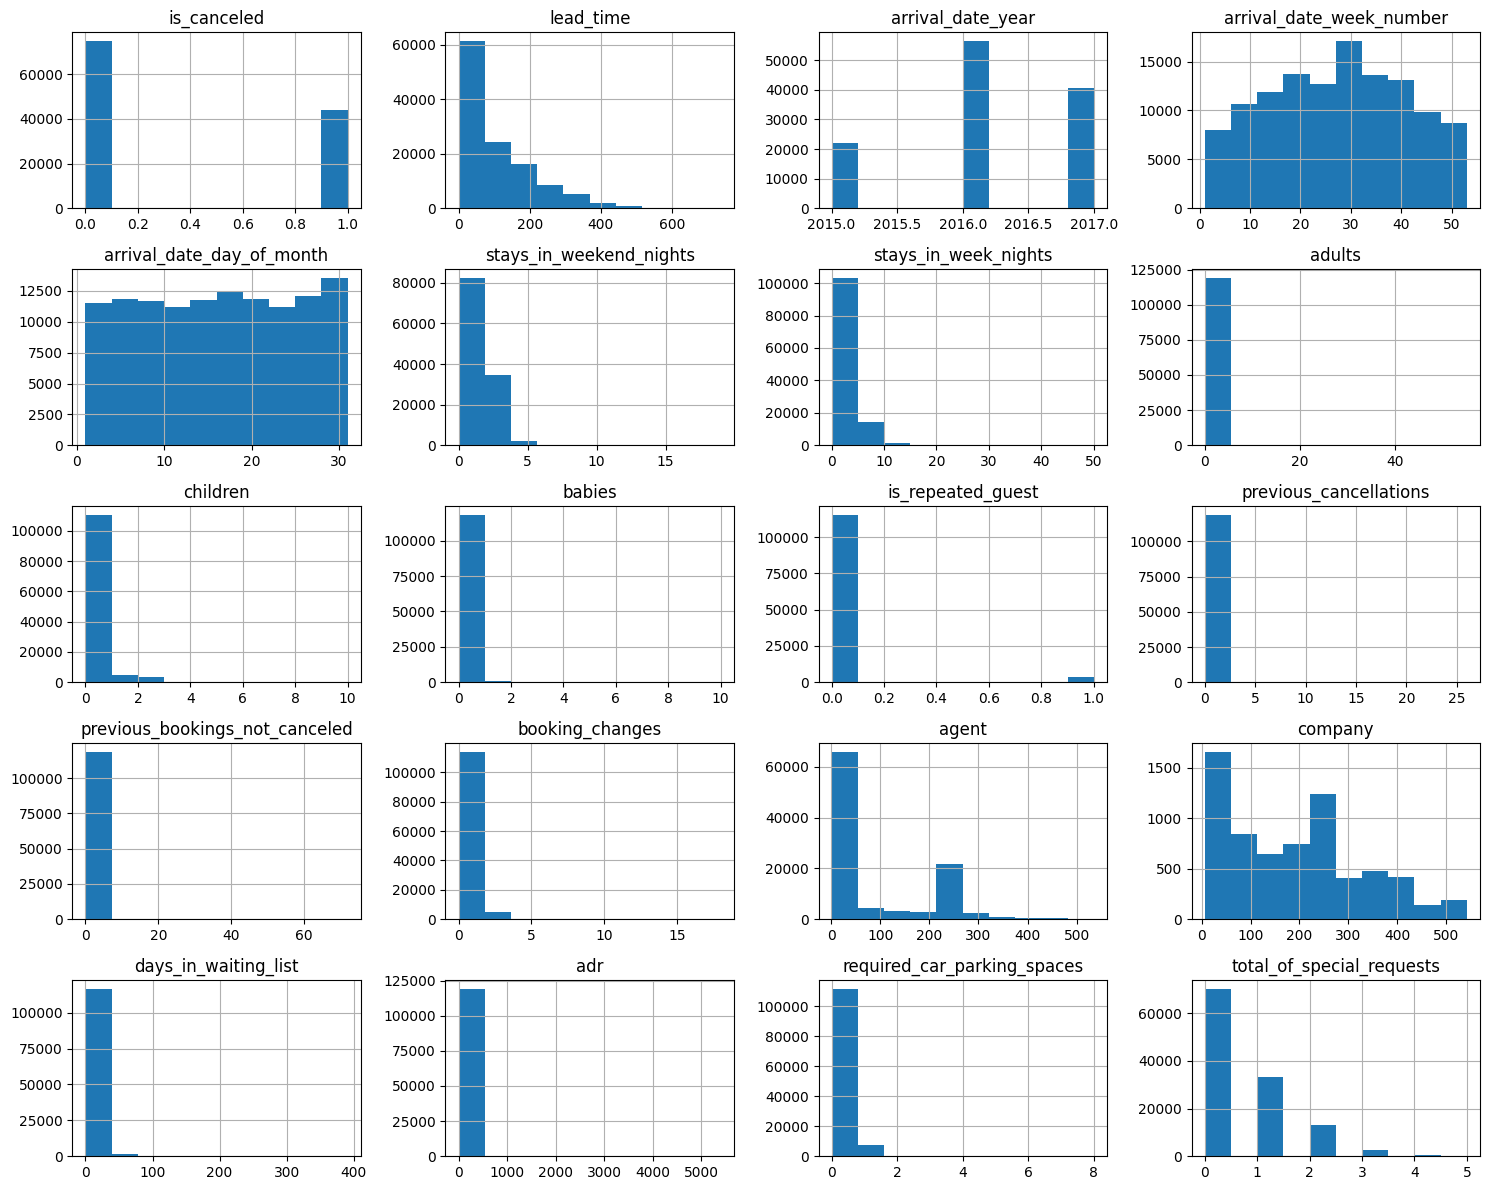

In [30]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

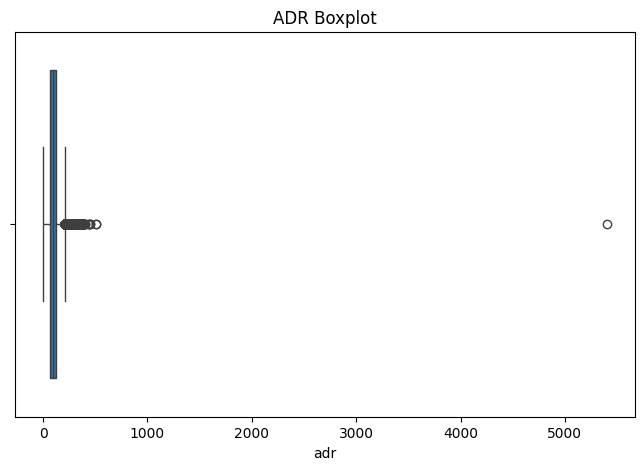

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['adr'])

plt.title("ADR Boxplot")

plt.show()

#*Outlier Detection*

In [32]:
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['adr'] < lower) | (df['adr'] > upper)]

print("Number of Outliers:", outliers.shape[0])

Number of Outliers: 3864


#Data Preprocessing

In [33]:
df.drop_duplicates(inplace=True)

print("Dataset Shape:", df.shape)

Dataset Shape: (87229, 32)


In [34]:
# Numerical
df['children'].fillna(df['children'].median(), inplace=True)

# Categorical
df['country'].fillna(df['country'].mode()[0], inplace=True)

# Missing values in agent and company mean no agent/company
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

In [35]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


#*Remove Data Leakage*

In [36]:
df.drop(['reservation_status',
         'reservation_status_date'],
        axis=1,
        inplace=True)

In [37]:
X = df.drop("is_canceled", axis=1)

y = df["is_canceled"]

#*Encode Categorical Features*

In [38]:
encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = encoder.fit_transform(X[col])

#*Split Dataset*

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#*Feature Scaling*

In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# **Model 1***(LogisticRegression)*

In [41]:
model1 = LogisticRegression(max_iter=1000)

model1.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [42]:
y_pred_lr = model1.predict(X_test_scaled)

y_prob_lr = model1.predict_proba(X_test_scaled)[:,1]

In [43]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Accuracy:", lr_accuracy)

Accuracy: 0.776338415682678


In [44]:
lr_precision = precision_score(y_test, y_pred_lr)

print("Precision:", lr_precision)

Precision: 0.6656848306332842


In [45]:
lr_recall = recall_score(y_test, y_pred_lr)

print("Recall:", lr_recall)

Recall: 0.3765097875885048


In [46]:
lr_f1 = f1_score(y_test, y_pred_lr)

print("F1 Score:", lr_f1)

F1 Score: 0.4809789837722799


In [47]:
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC:", lr_auc)

ROC-AUC: 0.8093532600238669


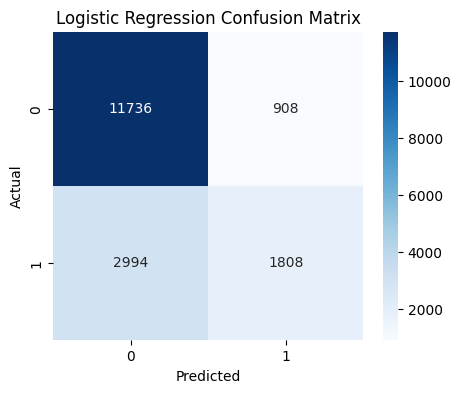

In [48]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [49]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86     12644
           1       0.67      0.38      0.48      4802

    accuracy                           0.78     17446
   macro avg       0.73      0.65      0.67     17446
weighted avg       0.76      0.78      0.75     17446



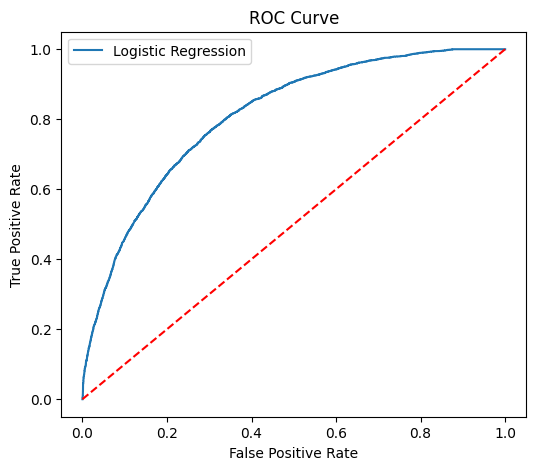

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Logistic Regression")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

#Model 2 *(RandomForest)*



In [51]:
model2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model2.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [52]:
y_pred_rf = model2.predict(X_test)

y_prob_rf = model2.predict_proba(X_test)[:,1]

In [53]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy:", rf_accuracy)

Accuracy: 0.8526309755817952


In [54]:
rf_precision = precision_score(y_test, y_pred_rf)

print("Precision:", rf_precision)

Precision: 0.7726717184062576


In [55]:
rf_recall = recall_score(y_test, y_pred_rf)

print("Recall:", rf_recall)

Recall: 0.6582673885880883


In [56]:
rf_f1 = f1_score(y_test, y_pred_rf)

print("F1 Score:", rf_f1)

F1 Score: 0.7108962105026425


In [57]:
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("ROC-AUC:", rf_auc)

ROC-AUC: 0.9141225032646816


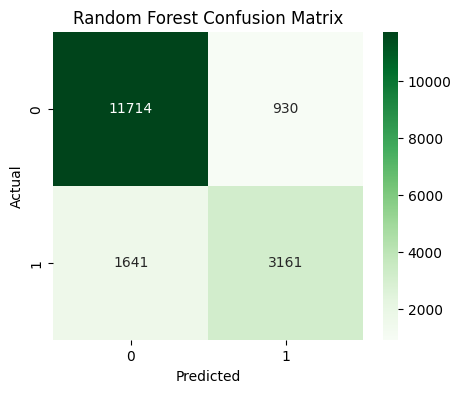

In [58]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [59]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90     12644
           1       0.77      0.66      0.71      4802

    accuracy                           0.85     17446
   macro avg       0.82      0.79      0.81     17446
weighted avg       0.85      0.85      0.85     17446



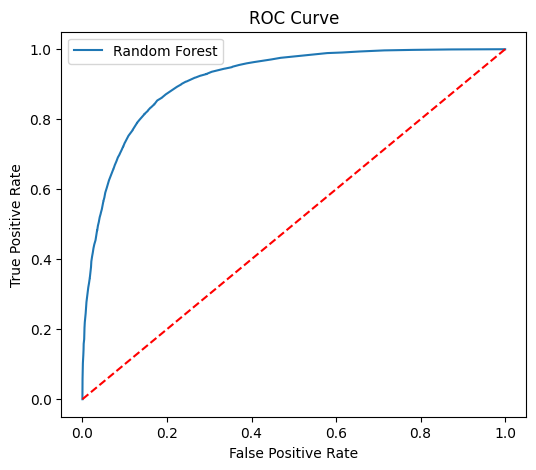

In [60]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

#Model 3 *(ANN)*


In [61]:
X_train_ann, X_val_ann, y_train_ann, y_val_ann = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

In [62]:
model3 = Sequential([

    Dense(256,
          activation='relu',
          input_shape=(X_train_scaled.shape[1],)),

    Dropout(0.2),

    Dense(128,
          activation='relu'),

    Dropout(0.2),

    Dense(64,
          activation='relu'),

    Dropout(0.1),

    Dense(32,
          activation='relu'),

    Dropout(0.1),

    Dense(1,
          activation='sigmoid')

])

In [63]:
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,945 (199.00 KB)

 Trainable params: 50,945 (199.00 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [65]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [66]:
history = model3.fit(
    X_train_ann,
    y_train_ann,
    validation_data=(X_val_ann, y_val_ann),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7855 - loss: 0.4470 - val_accuracy: 0.8066 - val_loss: 0.4051
Epoch 2/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8074 - loss: 0.4052 - val_accuracy: 0.8141 - val_loss: 0.3899
Epoch 3/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8157 - loss: 0.3897 - val_accuracy: 0.8172 - val_loss: 0.3851
Epoch 4/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8194 - loss: 0.3824 - val_accuracy: 0.8184 - val_loss: 0.3830
Epoch 5/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8224 - loss: 0.3760 - val_accuracy: 0.8232 - val_loss: 0.3782
Epoch 6/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8235 - loss: 0.3710 - val_accuracy: 0.8253 - val_loss: 0.3719
Epoch 7/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8277 - loss: 0.3668 - val_accuracy: 0.8278 - val_loss: 0.3734
Epoch 8/30
1745/1745 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8291 - loss: 0.3641 -

In [67]:
loss, ann_accuracy = model3.evaluate(
    X_test_scaled,
    y_test
)

print("Loss:", loss)
print("Accuracy:", ann_accuracy)

546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8364 - loss: 0.3464
Loss: 0.3464319705963135
Accuracy: 0.8364095091819763


In [68]:
y_prob_ann = model3.predict(X_test_scaled)

y_pred_ann = (y_prob_ann > 0.5).astype(int).flatten()

546/546 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [69]:
ann_precision = precision_score(y_test, y_pred_ann)

print("Precision:", ann_precision)

Precision: 0.7468322351748606


In [70]:
ann_recall = recall_score(y_test, y_pred_ann)

print("Recall:", ann_recall)

Recall: 0.6137026239067055


In [71]:
ann_f1 = f1_score(y_test, y_pred_ann)

print("F1 Score:", ann_f1)

F1 Score: 0.6737540009144948


In [72]:
ann_auc = roc_auc_score(y_test, y_prob_ann)

print("ROC-AUC:", ann_auc)

ROC-AUC: 0.9005205060608907


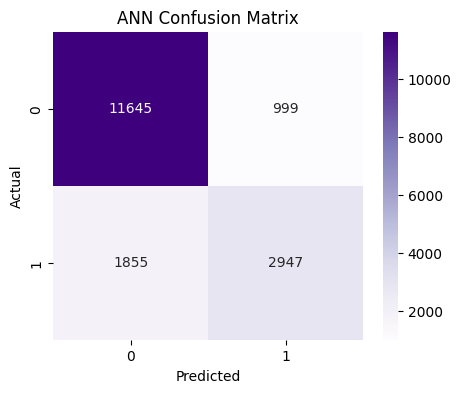

In [73]:
cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples')

plt.title("ANN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [74]:
print(classification_report(y_test, y_pred_ann))

              precision    recall  f1-score   support

           0       0.86      0.92      0.89     12644
           1       0.75      0.61      0.67      4802

    accuracy                           0.84     17446
   macro avg       0.80      0.77      0.78     17446
weighted avg       0.83      0.84      0.83     17446



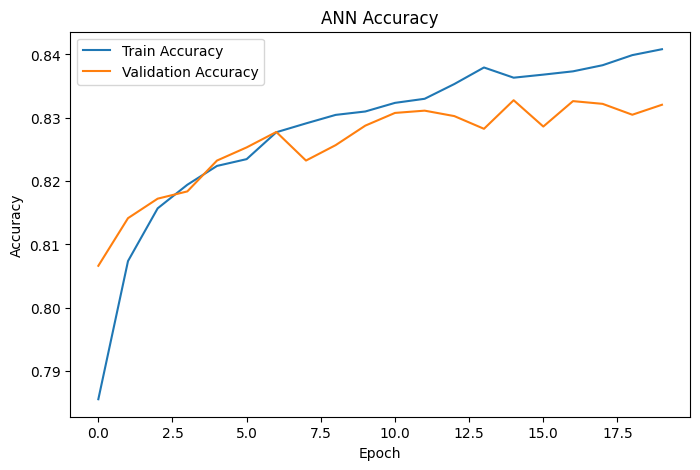

In [75]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("ANN Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.show()

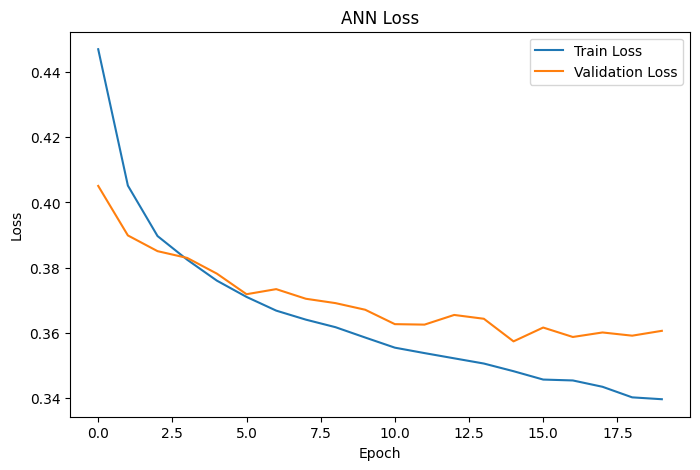

In [76]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("ANN Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

#*Compare All Models*

In [77]:
comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Artificial Neural Network'
    ],

    'Accuracy': [
        lr_accuracy,
        rf_accuracy,
        ann_accuracy
    ],

    'Precision': [
        lr_precision,
        rf_precision,
        ann_precision
    ],

    'Recall': [
        lr_recall,
        rf_recall,
        ann_recall
    ],

    'F1-Score': [
        lr_f1,
        rf_f1,
        ann_f1
    ],

    'ROC-AUC': [
        lr_auc,
        rf_auc,
        ann_auc
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.776338,0.665685,0.376510,0.480979,0.809353
1,Random Forest,0.852631,0.772672,0.658267,0.710896,0.914123
2,Artificial Neural Network,0.836410,0.746832,0.613703,0.673754,0.900521


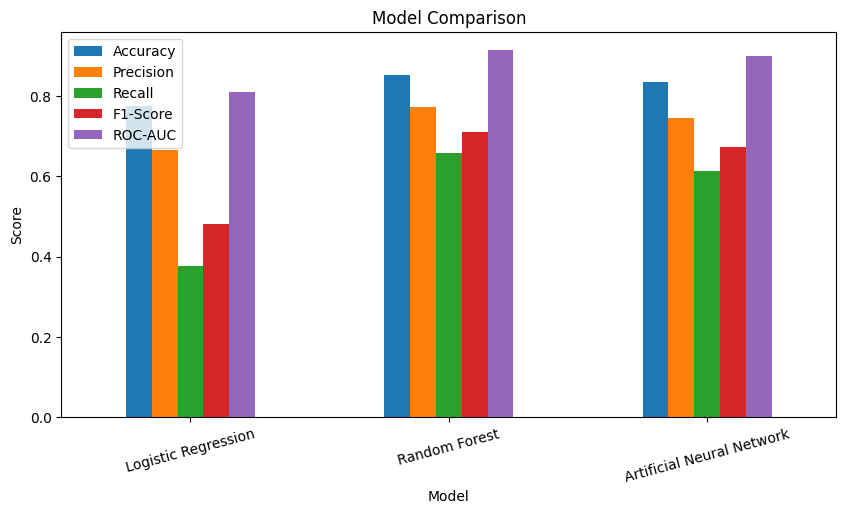

In [78]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=15)

plt.legend()

plt.show()

#*Best Model*

In [79]:
best_model = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best Model:", best_model["Model"])

print("Best Accuracy:", best_model["Accuracy"])

Best Model: Random Forest
Best Accuracy: 0.8526309755817952


In [80]:
best_model = comparison.loc[comparison["ROC-AUC"].idxmax()]

print("Best Model:", best_model["Model"])
print("Best ROC-AUC:", best_model["ROC-AUC"])

Best Model: Random Forest
Best ROC-AUC: 0.9141225032646816


#*Save Trained Models*

In [81]:
import joblib
joblib.dump(model1, "logistic_regression.pkl")
joblib.dump(model2, "random_forest.pkl")
model3.save("hotel_booking_ann.keras")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoder, "label_encoder.pkl")
import os
print(os.listdir())

['.config', 'logistic_regression.pkl', 'hotel_booking_ann.keras', 'label_encoder.pkl', 'scaler.pkl', 'hotel_bookings.csv', 'random_forest.pkl', 'sample_data']


#*Deployment*

In [82]:
import pickle
# 2. اختيار أهم المتغيرات لتبسيط واجهة الـ Deployment
features = ['hotel', 'lead_time', 'deposit_type', 'adr',
            'total_of_special_requests', 'required_car_parking_spaces',
            'customer_type', 'previous_cancellations']

X = df[features].copy()
y = df['is_canceled']

# 3. تحويل المتغيرات النصية (Encoding) وحفظ الـ Encoders
encoders = {}
categorical_features = ['hotel', 'deposit_type', 'customer_type']

for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le  # هنحفظ الـ encoder عشان نستخدمه في FastAPI بنفس الترتيب

# 4. تقسيم البيانات وتدريب الموديل
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# طباعة الدقة للتأكد
print(f"Model Training Accuracy: {model.score(X_train, y_train)*100:.2f}%")
print(f"Model Testing Accuracy: {model.score(X_test, y_test)*100:.2f}%")

# 5. حفظ الموديل والـ Encoders في ملفات خارجية
with open('hotel_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

print("تم حفظ الموديل والـ Encoders بنجاح! جاهزين للـ Deployment.")

Model Training Accuracy: 96.45%
Model Testing Accuracy: 75.28%
تم حفظ الموديل والـ Encoders بنجاح! جاهزين للـ Deployment.
